# Ch08 Object References, Mutability, and Recycling

In [1]:
a = [1, 2, 3]
b = a
a.append(4)
b

[1, 2, 3, 4]

In [2]:
class Gizmo:
    def __init__(self):
        #print('Gizmo id: %d' % id(self))
        print(f'Gizmo id: {id(self)}')

x = Gizmo()

Gizmo id: 132849518245408


In [3]:
y = Gizmo() * 10

Gizmo id: 132849520616912


TypeError: unsupported operand type(s) for *: 'Gizmo' and 'int'

In [4]:
dir()

['Gizmo',
 'In',
 'Out',
 '_',
 '_1',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'a',
 'b',
 'exit',
 'get_ipython',
 'open',
 'quit',
 'x']

## Identity, Equality, and Aliases

In [5]:
charles = {'name': 'Charles L. Dodgson', 'born': 1832, 'died': 1898}
lewis = charles
lewis 

{'name': 'Charles L. Dodgson', 'born': 1832, 'died': 1898}

In [6]:
lewis is charles

True

In [7]:
id(charles), id(lewis)

(132849099792192, 132849099792192)

In [8]:
lewis['balance'] = 950
charles

{'name': 'Charles L. Dodgson', 'born': 1832, 'died': 1898, 'balance': 950}

In [9]:
alex = {'name': 'Charles L. Dodgson', 'born': 1832, 'balance': 950, 'died': 1898}
alex == charles

True

In [10]:
alex is not charles

True

In [11]:
id(charles), id(alex)

(132849099792192, 132849100204160)

## Copies Are Shallow by Default

In [13]:
l1 = [3, [55, 44], (7, 8, 9)]
l2 = list(l1)
l1 == l2

True

In [14]:
l2 is l1

False

In [15]:
id(l1), id(l2)

(132849100208512, 132849100142272)

In [18]:
for i in range(3):
    print(id(l1[i]), id(l2[i]))

21909672 21909672
132849100195776 132849100195776
132849099785920 132849099785920


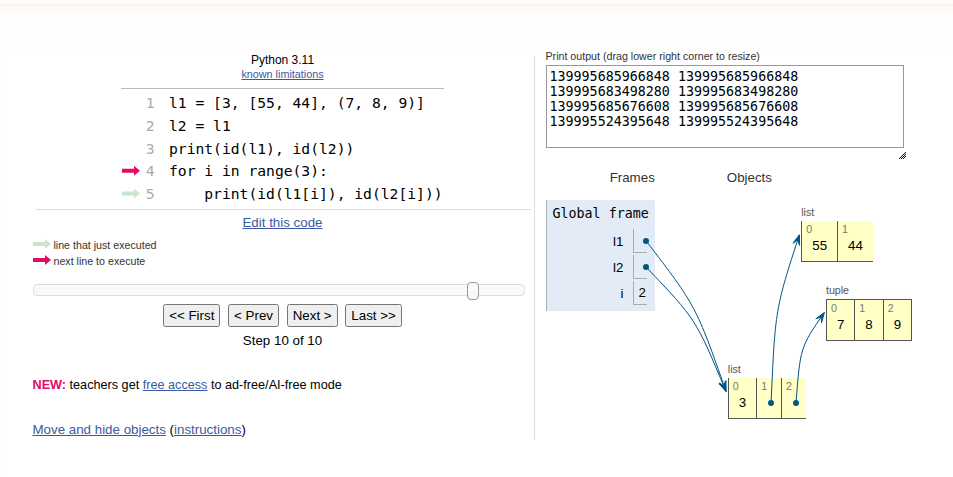

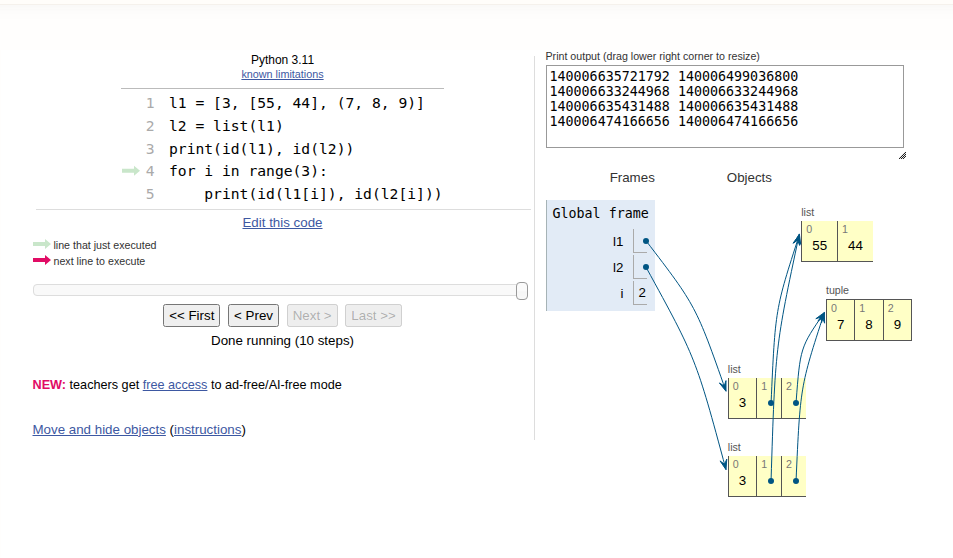

## Deep and Shallow Copies of Arbitrary Objects

In [19]:
class Bus:
    def __init__(self, passengers=None):
        if passengers is None:
            self.passengers = []
        else:
            self.passengers = list(passengers)

    def pick(self, name):
        self.passengers.append(name)

    def drop(self, name):
        self.passengers.remove(name)

In [20]:
import copy
bus1 = Bus(['Alice', 'Bill', 'Claire', 'David'])
bus2 = copy.copy(bus1)
bus3 = copy.deepcopy(bus1)

id(bus1), id(bus2), id(bus3)

(132849514793008, 132849520621392, 132849520621072)

In [21]:
bus1.drop('Bill')
bus2.passengers

['Alice', 'Claire', 'David']

In [22]:
id(bus1.passengers), id(bus2.passengers), id(bus3.passengers)

(132849100350272, 132849100350272, 132849100351936)

In [23]:
bus3.passengers

['Alice', 'Bill', 'Claire', 'David']

In [24]:
a = [10, 20]
b = [a, 30]
b

[[10, 20], 30]

In [25]:
a

[10, 20]

In [26]:
a.append(b)
a

[10, 20, [[...], 30]]

## Function Parameters as Reference

The only mode of parameter passing in Python is *call by sharing*. 

Call by sharing means that each formal parameter of the function gets a copy of each reference in the arguments.

In [1]:
def f(a, b):
    a += b
    return a

x = 1
y = 2
f(x, y)


3

In [2]:
x, y

(1, 2)

In [3]:
a = [1, 2]
b = [3, 4]
f(a, b)

[1, 2, 3, 4]

In [4]:
a, b

([1, 2, 3, 4], [3, 4])

In [5]:
t = (10, 20)
u = (30, 40)
f(t, u)

(10, 20, 30, 40)

In [6]:
t, u

((10, 20), (30, 40))

## Mutable Types as Parameter Defaults: Bad Idea

In [7]:
class HauntedBus:
    def __init__(self, passengers=[]):
        self.passengers = passengers 

    def pick(self, name):
        self.passengers.append(name)

    def drop(self, name):
        self.passengers.remove(name)

In [8]:
bus1 = HauntedBus(['Alice', 'Bill'])
bus1.passengers

['Alice', 'Bill']

In [9]:
bus1.pick('Charlie')
bus1.drop('Alice')
bus1.passengers

['Bill', 'Charlie']

In [10]:
bus2 = HauntedBus()
bus2.pick('Carrie')
bus2.passengers

['Carrie']

In [11]:
bus3 = HauntedBus()
bus3.passengers

['Carrie']

In [12]:
bus3.pick('Dave')
bus3.passengers


['Carrie', 'Dave']

In [13]:
bus2.passengers

['Carrie', 'Dave']

In [14]:
bus2.passengers is bus3.passengers

True

In [15]:
bus1.passengers is bus2.passengers

False

## Defensive Programming with Mutable Parameters

In [16]:
basketball_team =['Sue', 'Tina', 'Maya', 'Diana', 'Pat']
bus = HauntedBus(basketball_team)
bus.drop('Tina')
bus.drop('Pat')
basketball_team

['Sue', 'Maya', 'Diana']

In [ ]:
class TwilightBus:
    def __init__(self, passengers=None):
        if passengers is None:
            self.passengers = []
        else:
            self.passengers = passengers # Pay attention here!

    def pick(self, name):
        self.passengers.append(name)

    def drop(self, name):
        self.passengers.remove(name)

basketball_team =['Sue', 'Tina', 'Maya', 'Diana', 'Pat']
bus = TwilightBus(basketball_team)
bus.drop('Tina')
bus.drop('Pat')
basketball_team

['Sue', 'Maya', 'Diana']

In [ ]:
class DefensiveTwilightBus:
    def __init__(self, passengers=None):
        if passengers is None:
            self.passengers = []
        else:
            self.passengers = list(passengers) # Make a copy of the list, or convert it to a list if it's not one.

    def pick(self, name):
        self.passengers.append(name)

    def drop(self, name):
        self.passengers.remove(name)

basketball_team =['Sue', 'Tina', 'Maya', 'Diana', 'Pat']
bus = DefensiveTwilightBus(basketball_team)
bus.drop('Tina')
bus.drop('Pat')
basketball_team

['Sue', 'Tina', 'Maya', 'Diana', 'Pat']

In [19]:
bus.passengers

['Sue', 'Maya', 'Diana']